In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Cargar datos
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalización
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(x_train.shape, x_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


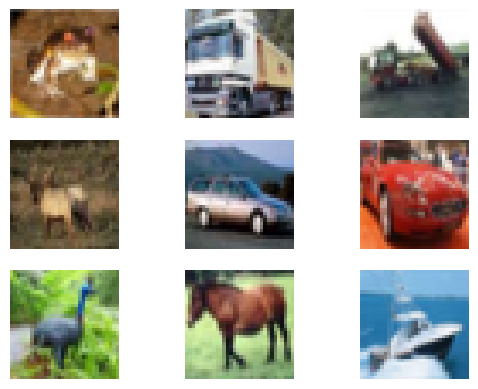

In [13]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()

In [14]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(x_train)

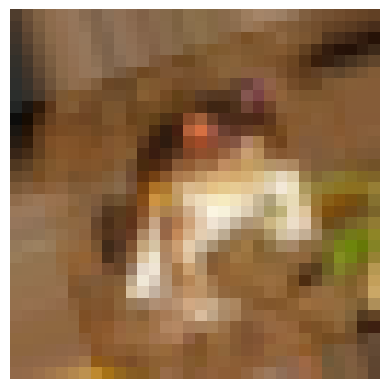

In [15]:
sample = x_train[0].reshape((1, 32, 32, 3))

i = 0
for batch in datagen.flow(sample, batch_size=1):
    plt.imshow(batch[0])
    plt.axis('off')
    i += 1
    if i > 4:
        break
plt.show()

In [18]:
def create_base_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D(),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_base = create_base_model()

history_base = model_base.fit(
    x_train, y_train,
    epochs=8,
    validation_data=(x_test, y_test)
)

Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.4742 - loss: 1.4629 - val_accuracy: 0.5834 - val_loss: 1.1827
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 44ms/step - accuracy: 0.6137 - loss: 1.0999 - val_accuracy: 0.6242 - val_loss: 1.0673
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.6602 - loss: 0.9726 - val_accuracy: 0.6605 - val_loss: 0.9904
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6905 - loss: 0.8878 - val_accuracy: 0.6739 - val_loss: 0.9500
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7134 - loss: 0.8212 - val_accuracy: 0.6808 - val_loss: 0.9266
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7316 - loss: 0.7691 - val_accuracy: 0.6839 - val_loss: 0.9123
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7474 - loss: 0.7227 - val_accuracy: 0.6878 - val_loss: 0.9437
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.7605 - loss: 0

In [19]:
model_aug = create_base_model()

history_aug = model_aug.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=8,
    validation_data=(x_test, y_test)
)

Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 64ms/step - accuracy: 0.3867 - loss: 1.6854 - val_accuracy: 0.5259 - val_loss: 1.3461
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 0.4996 - loss: 1.4015 - val_accuracy: 0.5589 - val_loss: 1.2310
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 101s 65ms/step - accuracy: 0.5399 - loss: 1.2922 - val_accuracy: 0.6192 - val_loss: 1.0938
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 65ms/step - accuracy: 0.5675 - loss: 1.2247 - val_accuracy: 0.6151 - val_loss: 1.0898
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 0.5821 - loss: 1.1867 - val_accuracy: 0.6359 - val_loss: 1.0506
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 100s 64ms/step - accuracy: 0.5947 - loss: 1.1510 - val_accuracy: 0.6440 - val_loss: 1.0246
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 65ms/step - accuracy: 0.6023 - loss: 1.1313 - val_accuracy: 0.6564 - val_loss: 0.9889
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 64ms/step - accuracy: 0.6119 -

In [20]:
# Cargar base preentrenada
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

# Congelar capas
for layer in base_model.layers:
    layer.trainable = False

# Agregar capas propias
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(10, activation='softmax')(x)

model_tl = Model(inputs=base_model.input, outputs=predictions)

model_tl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tl = model_tl.fit(
    x_train, y_train,
    epochs=8,
    validation_data=(x_test, y_test)
)

/tmp/ipykernel_12466/4188069597.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 50ms/step - accuracy: 0.2944 - loss: 1.9505 - val_accuracy: 0.3162 - val_loss: 1.8827
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.3263 - loss: 1.8559 - val_accuracy: 0.3281 - val_loss: 1.8551
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.3399 - loss: 1.8230 - val_accuracy: 0.3354 - val_loss: 1.8319
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.3468 - loss: 1.7985 - val_accuracy: 0.3415 - val_loss: 1.8229
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.3526 - loss: 1.7797 - val_accuracy: 0.3465 - val_loss: 1.8150
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.3586 - loss: 1.7641 - val_accuracy: 0.3490 - val_loss: 1.8106
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.3651 - loss: 1.7511 - val_accuracy: 0.3493 - val_loss: 1.8045
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.3683 - loss: 1

In [21]:
loss_base, acc_base = model_base.evaluate(x_test, y_test)
loss_aug, acc_aug = model_aug.evaluate(x_test, y_test)
loss_tl, acc_tl = model_tl.evaluate(x_test, y_test)

print("Modelo Base:", acc_base)
print("Data Augmentation:", acc_aug)
print("Transfer Learning:", acc_tl)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6877 - loss: 0.9042
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6634 - loss: 0.9619
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.3519 - loss: 1.8051
Modelo Base: 0.6876999735832214
Data Augmentation: 0.6633999943733215
Transfer Learning: 0.35190001130104065


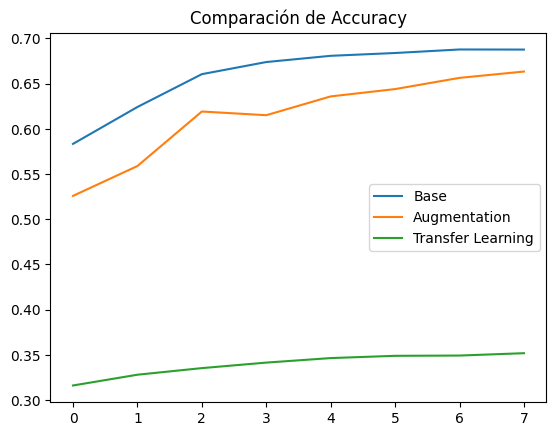

In [22]:
plt.plot(history_base.history['val_accuracy'], label='Base')
plt.plot(history_aug.history['val_accuracy'], label='Augmentation')
plt.plot(history_tl.history['val_accuracy'], label='Transfer Learning')
plt.legend()
plt.title("Comparación de Accuracy")
plt.show()

La data Augmentation mejora la generalización Reduce overfitting y Aumenta la diversidad del dataset, el transfer Learning entrena más rápido tiene un mejor desempeño con pocos datos y aprovecha el conocimiento previo con la función ImageNet, comparación esperada, Si tiene una base tiene un desempeño menor, con una augmentation mejora la estabilidad y el transfer Learning mejora el porcentaje de predicciones correctas del modelo